In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
#
# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
df = pd.read_csv('../titanic/train.csv')

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
X_train, X_test = train_test_split(df,test_size=0.2, random_state=42)

In [5]:
df.shape

(891, 12)

In [6]:
X_train.shape, X_test.shape

((712, 12), (179, 12))

In [7]:
X_train.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [8]:
df.isna().mean()

PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.198653
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Cabin          0.771044
Embarked       0.002245
dtype: float64

In [9]:
df['Ticket'].value_counts()

Ticket
347082             7
1601               7
CA. 2343           7
3101295            6
CA 2144            6
                  ..
SOTON/OQ 392076    1
211536             1
112053             1
111369             1
370376             1
Name: count, Length: 681, dtype: int64

In [10]:
X_train.drop(columns=['Name', 'Cabin', 'Ticket'], inplace=True)
X_test.drop(columns=['Name', 'Cabin', 'Ticket'], inplace=True)

In [11]:
X_train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
331,332,0,1,male,45.5,0,0,28.5000,S
733,734,0,2,male,23.0,0,0,13.0000,S
382,383,0,3,male,32.0,0,0,7.9250,S
704,705,0,3,male,26.0,1,0,7.8542,S
813,814,0,3,female,6.0,4,2,31.2750,S


In [12]:
X_train.groupby('Sex').agg({'Survived' : 'mean'})

,Survived
Sex,
female,0.738776
male,0.186296


In [13]:
X_train['gender_num'] = np.where(X_train['Sex'] == 'female', 1, 0)

In [14]:
X_test['gender_num'] = np.where(X_test['Sex'] == 'female', 1, 0)

In [15]:
X_train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,gender_num
331,332,0,1,male,45.5,0,0,28.5000,S,0
733,734,0,2,male,23.0,0,0,13.0000,S,0
382,383,0,3,male,32.0,0,0,7.9250,S,0
704,705,0,3,male,26.0,1,0,7.8542,S,0
813,814,0,3,female,6.0,4,2,31.2750,S,1


In [16]:
X_test.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,gender_num
709,710,1,3,male,NaN,1,1,15.2458,C,0
439,440,0,2,male,31.0,0,0,10.5000,S,0
840,841,0,3,male,20.0,0,0,7.9250,S,0
720,721,1,2,female,6.0,0,1,33.0000,S,1
39,40,1,3,female,14.0,1,0,11.2417,C,1


In [17]:
X_train.groupby('Embarked').agg({'Survived' : 'mean'})

,Survived
Embarked,
C,0.544000
Q,0.366667
S,0.335238


In [18]:
X_train['embarked_num'] = np.where(X_train['Embarked'] == 'C', 1, 0)
X_test['embarked_num'] = np.where(X_test['Embarked'] == 'C', 1, 0)

In [19]:
X_train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,gender_num,embarked_num
331,332,0,1,male,45.5,0,0,28.5000,S,0,0
733,734,0,2,male,23.0,0,0,13.0000,S,0,0
382,383,0,3,male,32.0,0,0,7.9250,S,0,0
704,705,0,3,male,26.0,1,0,7.8542,S,0,0
813,814,0,3,female,6.0,4,2,31.2750,S,1,0


In [20]:
X_train.drop(columns=['Sex', 'Embarked'], inplace=True)
X_test.drop(columns=['Sex', 'Embarked'], inplace=True)

In [21]:
X_train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,gender_num,embarked_num
331,332,0,1,45.5,0,0,28.5000,0,0
733,734,0,2,23.0,0,0,13.0000,0,0
382,383,0,3,32.0,0,0,7.9250,0,0
704,705,0,3,26.0,1,0,7.8542,0,0
813,814,0,3,6.0,4,2,31.2750,1,0


In [22]:
X_test.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,gender_num,embarked_num
709,710,1,3,NaN,1,1,15.2458,0,1
439,440,0,2,31.0,0,0,10.5000,0,0
840,841,0,3,20.0,0,0,7.9250,0,0
720,721,1,2,6.0,0,1,33.0000,1,0
39,40,1,3,14.0,1,0,11.2417,1,1


In [23]:
X_train.isna().mean()

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Age             0.196629
SibSp           0.000000
Parch           0.000000
Fare            0.000000
gender_num      0.000000
embarked_num    0.000000
dtype: float64

In [24]:
X_train['Age'].mode()

0    24.0
Name: Age, dtype: float64

In [25]:
X_train.fillna(24, inplace=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,gender_num,embarked_num
331,332,0,1,45.5,0,0,28.5000,0,0
733,734,0,2,23.0,0,0,13.0000,0,0
382,383,0,3,32.0,0,0,7.9250,0,0
704,705,0,3,26.0,1,0,7.8542,0,0
813,814,0,3,6.0,4,2,31.2750,1,0
...,...,...,...,...,...,...,...,...,...
106,107,1,3,21.0,0,0,7.6500,1,0
270,271,0,1,24.0,0,0,31.0000,0,0
860,861,0,3,41.0,2,0,14.1083,0,0
435,436,1,1,14.0,1,2,120.0000,1,0


In [26]:
X_test.fillna(24, inplace=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,gender_num,embarked_num
709,710,1,3,24.0,1,1,15.2458,0,1
439,440,0,2,31.0,0,0,10.5000,0,0
840,841,0,3,20.0,0,0,7.9250,0,0
720,721,1,2,6.0,0,1,33.0000,1,0
39,40,1,3,14.0,1,0,11.2417,1,1
...,...,...,...,...,...,...,...,...,...
433,434,0,3,17.0,0,0,7.1250,0,0
773,774,0,3,24.0,0,0,7.2250,0,1
25,26,1,3,38.0,1,5,31.3875,1,0
84,85,1,2,17.0,0,0,10.5000,1,0


In [27]:
X_train.isna().mean()

PassengerId     0.0
Survived        0.0
Pclass          0.0
Age             0.0
SibSp           0.0
Parch           0.0
Fare            0.0
gender_num      0.0
embarked_num    0.0
dtype: float64

In [28]:
X_test.isna().mean()

PassengerId     0.0
Survived        0.0
Pclass          0.0
Age             0.0
SibSp           0.0
Parch           0.0
Fare            0.0
gender_num      0.0
embarked_num    0.0
dtype: float64

In [29]:
X_train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,gender_num,embarked_num
331,332,0,1,45.5,0,0,28.5000,0,0
733,734,0,2,23.0,0,0,13.0000,0,0
382,383,0,3,32.0,0,0,7.9250,0,0
704,705,0,3,26.0,1,0,7.8542,0,0
813,814,0,3,6.0,4,2,31.2750,1,0


In [30]:
train_ids = X_train.pop('PassengerId')
y_train = X_train.pop('Survived')

test_ids = X_test.pop('PassengerId')
y_test = X_test.pop('Survived')

In [31]:
X_train.head()

,Pclass,Age,SibSp,Parch,Fare,gender_num,embarked_num
331,1,45.5,0,0,28.5000,0,0
733,2,23.0,0,0,13.0000,0,0
382,3,32.0,0,0,7.9250,0,0
704,3,26.0,1,0,7.8542,0,0
813,3,6.0,4,2,31.2750,1,0


In [32]:
X_test.head()

,Pclass,Age,SibSp,Parch,Fare,gender_num,embarked_num
709,3,24.0,1,1,15.2458,0,1
439,2,31.0,0,0,10.5000,0,0
840,3,20.0,0,0,7.9250,0,0
720,2,6.0,0,1,33.0000,1,0
39,3,14.0,1,0,11.2417,1,1


In [33]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((712, 7), (712,), (179, 7), (179,))

In [34]:
X_train.head()

,Pclass,Age,SibSp,Parch,Fare,gender_num,embarked_num
331,1,45.5,0,0,28.5000,0,0
733,2,23.0,0,0,13.0000,0,0
382,3,32.0,0,0,7.9250,0,0
704,3,26.0,1,0,7.8542,0,0
813,3,6.0,4,2,31.2750,1,0


In [35]:
y_train

331    0
733    0
382    0
704    0
813    0
      ..
106    1
270    0
860    0
435    1
102    0
Name: Survived, Length: 712, dtype: int64

In [36]:
from sklearn.linear_model import LinearRegression

model = LinearRegression().fit(X_train, y_train)


# Evaluate Train Set

In [37]:
prob_train = model.predict(X_train)

In [38]:
pred_train = np.where(prob_train > 0.5, 1, 0)

In [39]:
pred_train.mean(), y_train.mean()

(np.float64(0.3497191011235955), np.float64(0.37640449438202245))

In [40]:
from sklearn.metrics import *

accuracy_score(y_train, pred_train)

0.7935393258426966

In [41]:
confusion_matrix(y_train, pred_train)

array([[380,  64],
       [ 83, 185]])

In [42]:
print(classification_report(y_train, pred_train))

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       444
           1       0.74      0.69      0.72       268

    accuracy                           0.79       712
   macro avg       0.78      0.77      0.78       712
weighted avg       0.79      0.79      0.79       712



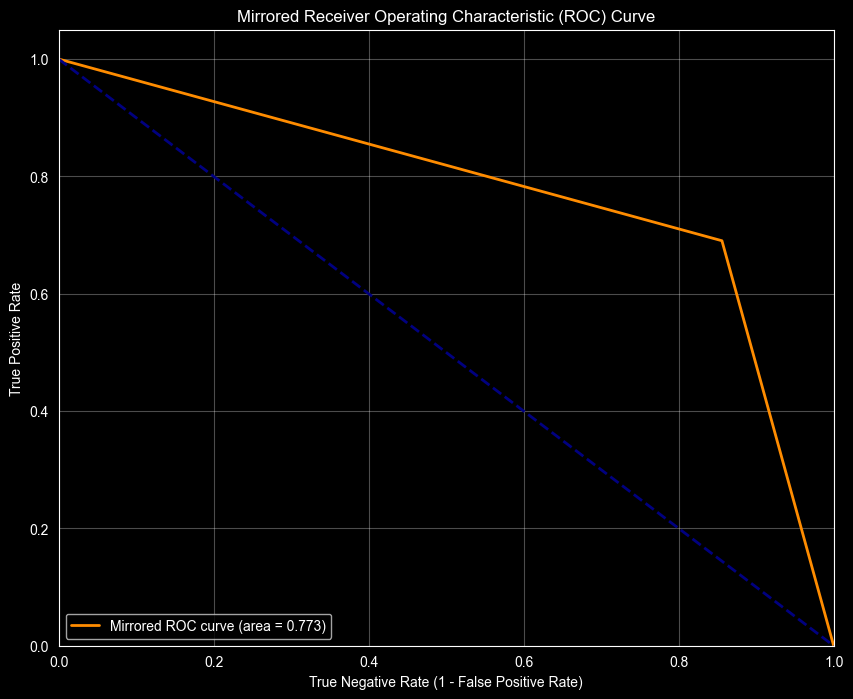

In [43]:
import numpy as np
import matplotlib.pyplot as plt


fpr, tpr, thresholds = roc_curve(y_train, pred_train)
roc_auc = auc(fpr, tpr)

# Mirror the x-axis by converting FPR to TNR (True Negative Rate)
tnr = 1 - fpr

# Create plot
plt.figure(figsize=(10, 8))

# Plot mirrored ROC curve (TPR vs TNR)
plt.plot(tnr, tpr, color='darkorange', lw=2, 
         label=f'Mirrored ROC curve (area = {roc_auc:.3f})')

# Plot diagonal line (represents random classifier)
plt.plot([0, 1], [1, 0], color='navy', lw=2, linestyle='--')

# Set plot properties
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('True Negative Rate (1 - False Positive Rate)')
plt.ylabel('True Positive Rate')
plt.title('Mirrored Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower left")

# Display the plot
plt.grid(alpha=0.3)
plt.show()

# Evaluate Train Set

In [44]:
prob_test = model.predict(X_test)

In [45]:
pred_test = np.where(prob_test > 0.5, 1, 0)

In [46]:
print(classification_report(y_test, pred_test))

              precision    recall  f1-score   support

           0       0.79      0.83      0.81       105
           1       0.74      0.69      0.71        74

    accuracy                           0.77       179
   macro avg       0.77      0.76      0.76       179
weighted avg       0.77      0.77      0.77       179



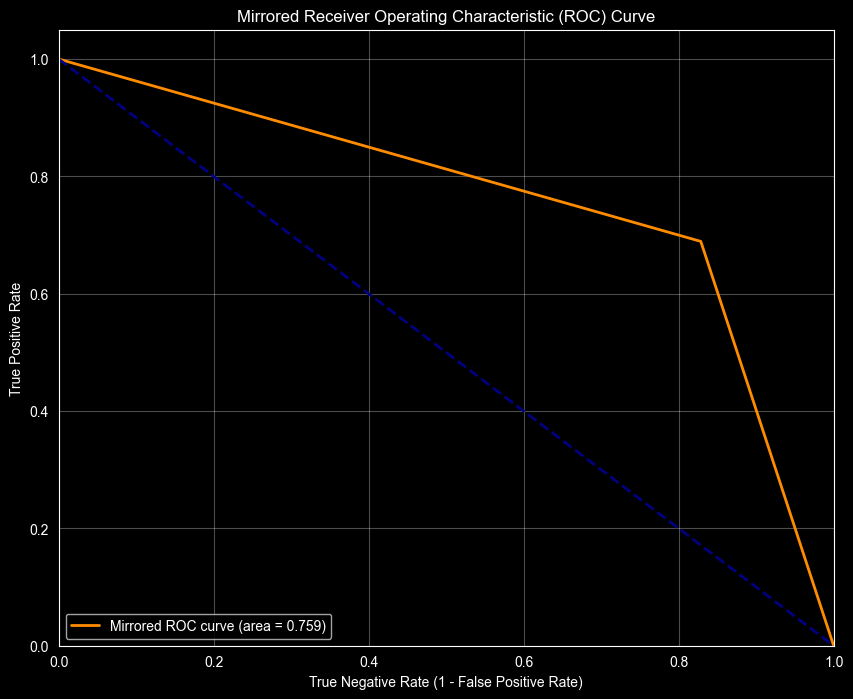

In [47]:
fpr, tpr, thresholds = roc_curve(y_test, pred_test)
roc_auc = auc(fpr, tpr)

# Mirror the x-axis by converting FPR to TNR (True Negative Rate)
tnr = 1 - fpr

# Create plot
plt.figure(figsize=(10, 8))

# Plot mirrored ROC curve (TPR vs TNR)
plt.plot(tnr, tpr, color='darkorange', lw=2, 
         label=f'Mirrored ROC curve (area = {roc_auc:.3f})')

# Plot diagonal line (represents random classifier)
plt.plot([0, 1], [1, 0], color='navy', lw=2, linestyle='--')

# Set plot properties
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('True Negative Rate (1 - False Positive Rate)')
plt.ylabel('True Positive Rate')
plt.title('Mirrored Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower left")

# Display the plot
plt.grid(alpha=0.3)
plt.show()